# Spectral Folding for ODMR Data

This notebook introduces **spectral folding** — a technique borrowed from Mössbauer spectroscopy that exploits the mirror symmetry of ODMR spectra.

The two frequency ranges measured in a QDM experiment are related by:
```
f± = D ± γ·B·cos(θ)
```
where D ~ 2.870 GHz is the zero-field splitting. They are mirror images about D — exactly like the two velocity-ramp halves in a Mössbauer spectrum. Folding them together gives:
- **√2 SNR improvement** in the combined spectrum
- **D_ZFS map** (per-pixel temperature/strain)
- **Fold residual** (model-free data quality metric)

We will work through:
1. Inspecting a real ODMR spectrum and its low/high symmetry
2. Finding the fold centre from the mean spectrum
3. Two-scale D_ZFS estimation — coarse binning → D map → bicubic interpolation
4. Per-pixel folding using the D_ZFS map
5. Interpreting the fold residual as a quality map

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import zoom

from qdmpy_core.measurement import Measurement
from qdmpy_core.constants import D_ZFS, GAMMA_NV

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

2026-02-28 07:02:37.854 | INFO     | qdmpy_core.fitting.models:register:395 - Registered model: ESR14N


2026-02-28 07:02:37.854 | INFO     | qdmpy_core.fitting.models:register:395 - Registered model: ESR15N


2026-02-28 07:02:37.855 | INFO     | qdmpy_core.fitting.models:register:395 - Registered model: ESRSINGLE


## 1. Load data and inspect the spectrum

We use the MIL2_FOV1 dataset, 4×4 spatially binned for speed.
The processed data has shape `(n_pol, n_frange, ny, nx, n_freq)`.

In [2]:
m = Measurement.from_folder('../tests/data/MIL2_FOV1', bin_factor=4, normalize=True)
data = m.odmr.processed_data.data
freq_ghz = data.coords['freq_ghz'].values   # (n_frange, n_freq)

print(f'Shape:      {data.shape}  (pol, frange, y, x, freq)')
print(f'Freq low:   {freq_ghz[0, 0]:.4f} – {freq_ghz[0, -1]:.4f} GHz')
print(f'Freq high:  {freq_ghz[1, 0]:.4f} – {freq_ghz[1, -1]:.4f} GHz')
print(f'D_ZFS lies at {D_ZFS:.3f} GHz — between the two ranges')

2026-02-28 07:02:38.484 | INFO     | qdmpy_core.measurement:from_folder:174 - Loading measurement from ../tests/data/MIL2_FOV1


2026-02-28 07:02:38.485 | INFO     | qdmpy_core.odmr.data:from_loader:87 - Loading ODMR data using loader: MatlabLoader


2026-02-28 07:02:38.486 | INFO     | qdmpy_core.odmr.io:load:82 - Found 2 MATLAB file(s) in ../tests/data/MIL2_FOV1


2026-02-28 07:02:53.453 | INFO     | qdmpy_core.odmr.io:load:151 - MATLAB data loaded in 14.97s — shape (2, 2, 1200, 1920, 51)


2026-02-28 07:02:53.618 | INFO     | qdmpy_core.odmr.manager:process_data:94 - Processing data.


...

2026-02-28 07:02:57.543 | WARNING  | qdmpy_core.measurement:_load_image_or_zeros:225 - No light image found in ../tests/data/MIL2_FOV1; using zeros array of shape (300, 480)


2026-02-28 07:02:57.627 | INFO     | qdmpy_core.io:get_image:100 - Loaded image ../tests/data/MIL2_FOV1/laser.csv with shape (1200, 1920)


2026-02-28 07:02:57.628 | INFO     | qdmpy_core.measurement:__init__:84 - Initializing Measurement object.


2026-02-28 07:02:57.629 | INFO     | qdmpy_core.measurement:__init__:85 - Output directory: "../tests/data/MIL2_FOV1/results"


Shape:      (2, 2, 300, 480, 51)  (pol, frange, y, x, freq)
Freq low:   2.8383 – 2.8513 GHz
Freq high:  2.8894 – 2.9024 GHz
D_ZFS lies at 2.870 GHz — between the two ranges


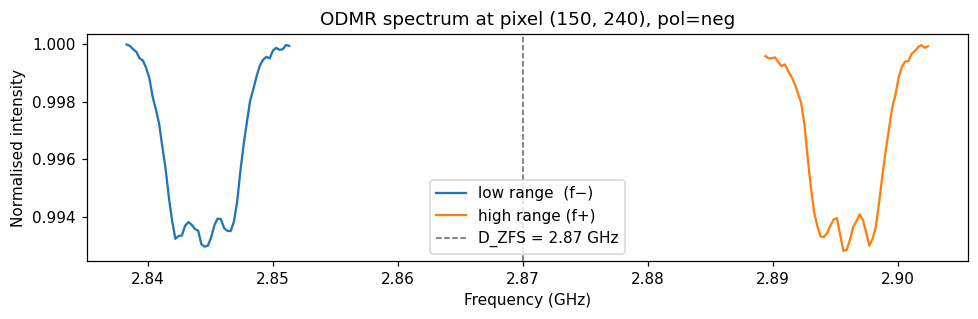

In [3]:
# Pick a centre pixel and show the full ODMR spectrum (low + high concatenated)
cy, cx = data.sizes['y'] // 2, data.sizes['x'] // 2
pol = 'neg'

spec_low  = data.sel(polarity=pol, freq_range='low').values[cy, cx, :]
spec_high = data.sel(polarity=pol, freq_range='high').values[cy, cx, :]
f_low, f_high = freq_ghz[0], freq_ghz[1]

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(f_low,  spec_low,  'tab:blue',   lw=1.5, label='low range  (f−)')
ax.plot(f_high, spec_high, 'tab:orange', lw=1.5, label='high range (f+)')
ax.axvline(D_ZFS, color='0.4', ls='--', lw=1, label=f'D_ZFS = {D_ZFS} GHz')
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Normalised intensity')
ax.set_title(f'ODMR spectrum at pixel ({cy}, {cx}), pol={pol}')
ax.legend()
plt.tight_layout()
plt.show()

The two dips are roughly symmetric about D_ZFS. The left dip (f−) and right dip (f+) are separated by 2γB — the Zeeman splitting from the sample's magnetic field.

**Fold idea:** reflect the high-range spectrum about D and add it to the low-range spectrum. If D is exactly right, the two dips line up perfectly.

## 2. Finding the fold centre from the mean spectrum

The mean spectrum averages over all pixels, giving very high SNR. We sweep candidate D values and find the one that best aligns the two halves.

In [4]:
def fold_residual_vs_d(s_low, s_high, f_low, f_high, d_candidates):
    """For each candidate D, compare S_low(D − δf) with S_high(D + δf).
    
    Both spectra are projected onto a common Zeeman-offset axis δf > 0.
    The valid δf range is determined by the inner and outer boundaries of
    the two frequency ranges:
    
        δf_inner = max(D − f_low[-1],  f_high[0]  − D)   # gap sets inner bound
        δf_outer = min(D − f_low[0],   f_high[-1] − D)   # shorter range sets outer
    
    This correctly handles asymmetric positions of D relative to the ranges.
    """
    step = np.median(np.diff(f_low))
    residuals = np.full(len(d_candidates), np.inf)
    for i, d in enumerate(d_candidates):
        df_inner = max(d - f_low[-1], f_high[0] - d)
        df_outer = min(d - f_low[0],  f_high[-1] - d)
        if df_outer - df_inner < 3 * step:
            continue
        delta_f = np.arange(df_inner, df_outer, step)
        left  = np.interp(d - delta_f, f_low,  s_low)
        right = np.interp(d + delta_f, f_high, s_high)
        residuals[i] = np.mean((left - right) ** 2)
    return residuals

In [5]:
# Compute mean spectrum across all pixels for one polarity
mean_low  = data.sel(polarity='neg', freq_range='low').values.mean(axis=(0, 1))
mean_high = data.sel(polarity='neg', freq_range='high').values.mean(axis=(0, 1))

# Sweep candidate D values. ±5 MHz is sufficient (±68 K equivalent) and avoids
# spurious near-zero residuals at the edges of the valid overlap region where too
# few frequency points are compared.
d_candidates = np.linspace(D_ZFS - 0.005, D_ZFS + 0.005, 401)
residuals = fold_residual_vs_d(mean_low, mean_high, f_low, f_high, d_candidates)

D_mean = d_candidates[np.argmin(residuals)]
print(f'Mean-spectrum fold centre: {D_mean:.6f} GHz')
print(f'Deviation from nominal D:  {(D_mean - D_ZFS)*1000:.3f} MHz')

Mean-spectrum fold centre: 2.870050 GHz
Deviation from nominal D:  0.050 MHz


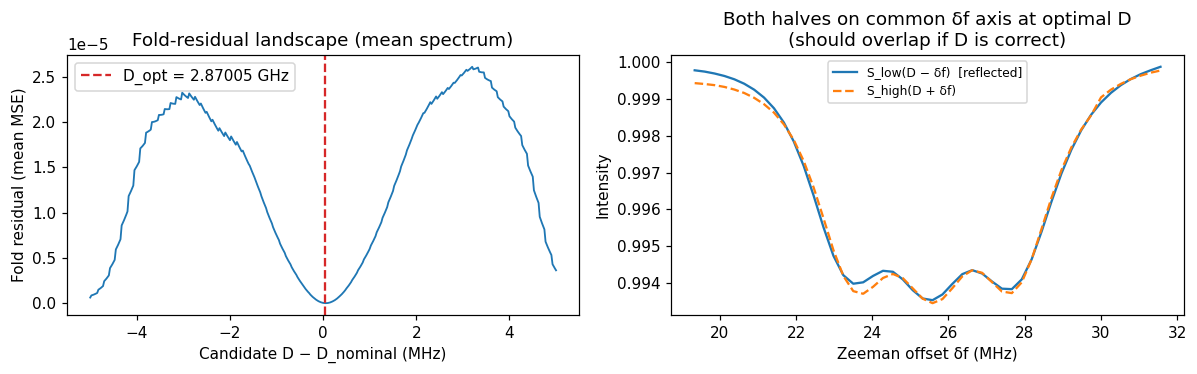

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

# Left: residual landscape
finite = np.isfinite(residuals)
ax1.plot((d_candidates[finite] - D_ZFS) * 1000, residuals[finite], 'tab:blue', lw=1.2)
ax1.axvline((D_mean - D_ZFS) * 1000, color='tab:red', ls='--',
            label=f'D_opt = {D_mean:.5f} GHz')
ax1.set_xlabel('Candidate D − D_nominal (MHz)')
ax1.set_ylabel('Fold residual (mean MSE)')
ax1.set_title('Fold-residual landscape (mean spectrum)')
ax1.legend()

# Right: both spectra on the common Zeeman-offset axis δf.
# S_low(D − δf) is the left half reflected to positive δf.
# S_high(D + δf) is the right half, naturally positive.
# At the true D, the two curves should overlap.
step = np.median(np.diff(f_low))
df_inner = max(D_mean - f_low[-1], f_high[0] - D_mean)
df_outer = min(D_mean - f_low[0],  f_high[-1] - D_mean)
delta_f_plot = np.arange(df_inner, df_outer, step)

s_left  = np.interp(D_mean - delta_f_plot, f_low,  mean_low)
s_right = np.interp(D_mean + delta_f_plot, f_high, mean_high)

ax2.plot(delta_f_plot * 1000, s_left,  'tab:blue',   lw=1.5, label='S_low(D − δf)  [reflected]')
ax2.plot(delta_f_plot * 1000, s_right, 'tab:orange', lw=1.5, ls='--', label='S_high(D + δf)')
ax2.set_xlabel('Zeeman offset δf (MHz)')
ax2.set_ylabel('Intensity')
ax2.set_title('Both halves on common δf axis at optimal D\n(should overlap if D is correct)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Two-scale D_ZFS estimation

**Problem:** per-pixel SNR is too low for precise D estimation (~150 K temperature precision).

**Solution:** temperature and strain vary on long spatial scales (millimetres). We can:
1. Heavily bin the data spatially (e.g. 8×8 extra bins)
2. Each super-pixel averages 64 pixels → √64 = 8× better SNR → ~19 K precision
3. Find D_ZFS at this coarse resolution
4. Bicubic-interpolate back to the original resolution

The interpolation is valid because D varies smoothly — a fine-scale D_ZFS map would just be noise.

In [7]:
def find_d_zfs_map(spectra_low, spectra_high, f_low, f_high,
                   d_initial=D_ZFS, search_range=0.005, n_steps=101):
    """Vectorized fold-point search across all pixels simultaneously.
    
    For each candidate D, projects both spectra onto the common Zeeman-offset
    axis δf and computes mean((S_low(D−δf) − S_high(D+δf))²) over the valid
    overlap window.  search_range=0.005 GHz (±5 MHz, ±68 K equivalent) avoids
    spurious near-zero minima at the edges of the valid overlap region.
    
    Args:
        spectra_low:  (ny, nx, n_freq)
        spectra_high: (ny, nx, n_freq)
        f_low, f_high: 1D frequency arrays (GHz)
        
    Returns:
        d_zfs_map: (ny, nx) in GHz
    """
    ny, nx = spectra_low.shape[:2]
    step = np.median(np.diff(f_low))
    d_candidates = np.linspace(d_initial - search_range,
                               d_initial + search_range, n_steps)
    
    residuals = np.full((n_steps, ny, nx), np.inf)
    flat_low  = spectra_low.reshape(-1, spectra_low.shape[-1])
    flat_high = spectra_high.reshape(-1, spectra_high.shape[-1])
    
    for i, d in enumerate(d_candidates):
        df_inner = max(d - f_low[-1], f_high[0] - d)
        df_outer = min(d - f_low[0],  f_high[-1] - d)
        if df_outer - df_inner < 3 * step:
            continue

        delta_f = np.arange(df_inner, df_outer, step)

        # Vectorized interpolation of S_low(D − δf) and S_high(D + δf)
        idx_l = np.interp(d - delta_f, f_low,  np.arange(len(f_low)))
        idx_h = np.interp(d + delta_f, f_high, np.arange(len(f_high)))
        idx_lo_l = np.clip(np.floor(idx_l).astype(int), 0, len(f_low)  - 2)
        idx_lo_h = np.clip(np.floor(idx_h).astype(int), 0, len(f_high) - 2)
        frac_l = idx_l - idx_lo_l
        frac_h = idx_h - idx_lo_h

        s_l = (flat_low[:,  idx_lo_l] * (1 - frac_l)
             + flat_low[:,  idx_lo_l + 1] * frac_l)
        s_h = (flat_high[:, idx_lo_h] * (1 - frac_h)
             + flat_high[:, idx_lo_h + 1] * frac_h)

        residuals[i] = ((s_l - s_h) ** 2).mean(axis=1).reshape(ny, nx)
    
    best_idx = np.argmin(residuals, axis=0)
    return d_candidates[best_idx]

In [8]:
# Step 1: create a coarse version by spatial averaging (8×8 blocks)
BIN = 8
coarse = data.coarsen(y=BIN, x=BIN, boundary='trim').mean()

print(f'Full resolution: {data.sizes["y"]} × {data.sizes["x"]} pixels')
print(f'Coarse:          {coarse.sizes["y"]} × {coarse.sizes["x"]} super-pixels')
print(f'SNR gain:        {np.sqrt(BIN**2):.0f}×')

Full resolution: 300 × 480 pixels
Coarse:          37 × 60 super-pixels
SNR gain:        8×


In [9]:
# Step 2: find D_ZFS at coarse resolution (fast — small array)
coarse_low  = coarse.sel(polarity='neg', freq_range='low').values   # (ny/8, nx/8, n_freq)
coarse_high = coarse.sel(polarity='neg', freq_range='high').values

d_zfs_coarse = find_d_zfs_map(coarse_low, coarse_high, f_low, f_high)
print(f'Coarse D_ZFS range: {d_zfs_coarse.min():.6f} – {d_zfs_coarse.max():.6f} GHz')

Coarse D_ZFS range: 2.869800 – 2.870300 GHz


In [10]:
# Step 3: bicubic interpolation back to full resolution
# Use per-axis zoom factors so the output matches the original image size exactly
# (integer binning gives floor(300/8)=37 rows, and 37*8=296 ≠ 300)
zoom_y = data.sizes['y'] / d_zfs_coarse.shape[0]
zoom_x = data.sizes['x'] / d_zfs_coarse.shape[1]
d_zfs_full = zoom(d_zfs_coarse, (zoom_y, zoom_x), order=3)   # order=3 = bicubic

# Trim to original dimensions (guards against floating-point rounding)
ny_full, nx_full = data.sizes['y'], data.sizes['x']
d_zfs_full = d_zfs_full[:ny_full, :nx_full]

print(f'Interpolated D_ZFS map shape: {d_zfs_full.shape}')

Interpolated D_ZFS map shape: (300, 480)


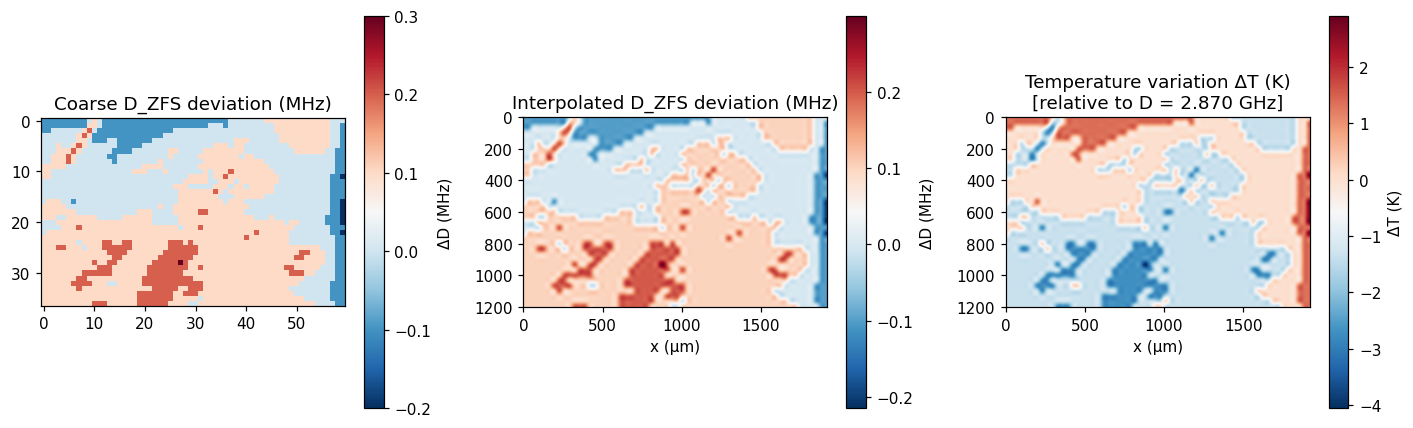

D_ZFS range: -0.214 – 0.299 MHz
ΔT range:    -4.0 – 2.9 K

Note: ΔD includes both temperature (dD/dT = −74 kHz/K) and strain contributions.
The reference D = 2.870 GHz is the free-diamond value; this sample may have a
fixed offset from strain, so only pixel-to-pixel variation has physical meaning.


In [11]:
# Convert D_ZFS deviation to temperature (dD/dT = -74 kHz/K)
D_ZFS_TEMP_COEFF = -74e-6   # GHz/K
delta_T = (d_zfs_full - D_ZFS) / D_ZFS_TEMP_COEFF
pixel_um = m.pixel_spacing * 1e6

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Coarse D_ZFS map — show deviation in MHz
im0 = axes[0].imshow((d_zfs_coarse - D_ZFS) * 1000,
                     cmap='RdBu_r', interpolation='nearest')
axes[0].set_title('Coarse D_ZFS deviation (MHz)')
fig.colorbar(im0, ax=axes[0], label='ΔD (MHz)')

# Interpolated D_ZFS map
ny, nx = d_zfs_full.shape
ext = [0, nx * pixel_um, ny * pixel_um, 0]
im1 = axes[1].imshow((d_zfs_full - D_ZFS) * 1000,
                     extent=ext, cmap='RdBu_r')
axes[1].set_title('Interpolated D_ZFS deviation (MHz)')
axes[1].set_xlabel('x (µm)')
fig.colorbar(im1, ax=axes[1], label='ΔD (MHz)')

# Temperature map
im2 = axes[2].imshow(delta_T, extent=ext, cmap='RdBu_r')
axes[2].set_title('Temperature variation ΔT (K)\n[relative to D = 2.870 GHz]')
axes[2].set_xlabel('x (µm)')
fig.colorbar(im2, ax=axes[2], label='ΔT (K)')

plt.tight_layout()
plt.show()

print(f'D_ZFS range: {(d_zfs_full.min()-D_ZFS)*1000:.3f} – {(d_zfs_full.max()-D_ZFS)*1000:.3f} MHz')
print(f'ΔT range:    {delta_T.min():.1f} – {delta_T.max():.1f} K')
print()
print('Note: ΔD includes both temperature (dD/dT = −74 kHz/K) and strain contributions.')
print('The reference D = 2.870 GHz is the free-diamond value; this sample may have a')
print('fixed offset from strain, so only pixel-to-pixel variation has physical meaning.')

## 4. Per-pixel fold using the D_ZFS map

Now we use `d_zfs_full` as the fold point for every pixel. Instead of assuming D = 2.870 GHz everywhere, each pixel folds around its own locally-measured D.

The folded spectrum is:
```
S_folded(δf) = S_low(D - δf) + S_high(D + δf)
```
where δf = γ·B is the Zeeman shift. The frequency axis of the folded spectrum is in units of Zeeman shift (GHz) — directly proportional to B field.

In [12]:
def fold_spectrum(s_low, s_high, f_low, f_high, d):
    """Fold one pixel's low+high spectra about D.
    
    Returns:
        delta_f: 1D frequency offset axis (GHz, from 0 to max Zeeman reach)
        s_folded: 1D folded spectrum (sum of the two halves)
    """
    # Symmetric reach from D: how far we can go before leaving either range
    reach = min(d - f_low[0], f_high[-1] - d)
    step  = np.median(np.diff(f_low))
    delta_f = np.arange(0, reach, step)
    
    # Interpolate S_low at D - delta_f and S_high at D + delta_f
    left  = np.interp(d - delta_f, f_low,  s_low)
    right = np.interp(d + delta_f, f_high, s_high)
    
    return delta_f, left + right

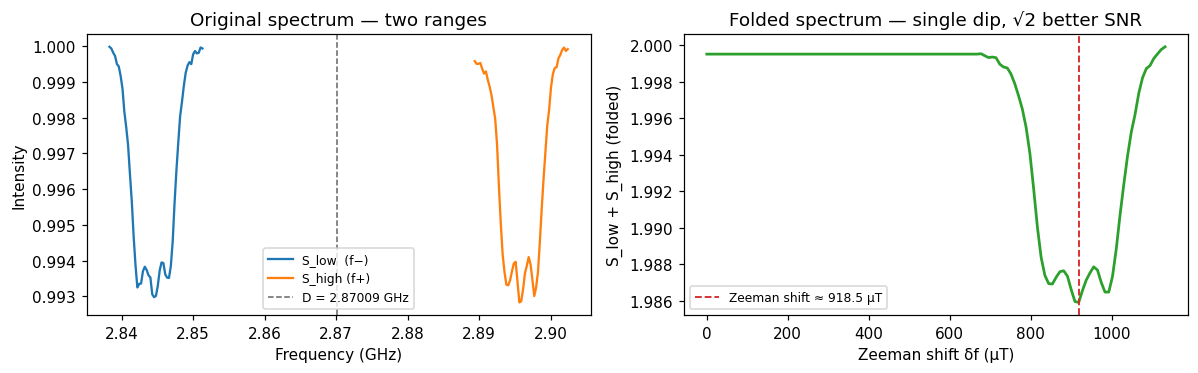

Zeeman shift at pixel (150,240): 918.5 µT  →  B ≈ 918.5 µT


In [13]:
# Compare original vs folded spectrum for the centre pixel
d_pixel = d_zfs_full[cy, cx]

s_low_px  = data.sel(polarity='neg', freq_range='low').values[cy, cx, :]
s_high_px = data.sel(polarity='neg', freq_range='high').values[cy, cx, :]

delta_f, s_folded = fold_spectrum(s_low_px, s_high_px, f_low, f_high, d_pixel)

# Convert delta_f axis to µT for physical intuition
delta_f_uT = delta_f / GAMMA_NV * 1e6

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

# Original spectrum
ax1.plot(f_low,  s_low_px,  'tab:blue',   lw=1.5, label='S_low  (f−)')
ax1.plot(f_high, s_high_px, 'tab:orange', lw=1.5, label='S_high (f+)')
ax1.axvline(d_pixel, color='0.4', ls='--', lw=1, label=f'D = {d_pixel:.5f} GHz')
ax1.set_xlabel('Frequency (GHz)')
ax1.set_ylabel('Intensity')
ax1.set_title('Original spectrum — two ranges')
ax1.legend(fontsize=8)

# Folded spectrum
ax2.plot(delta_f_uT, s_folded, 'tab:green', lw=1.8)
# Mark the Zeeman dip position
dip_uT = delta_f_uT[np.argmin(s_folded)]
ax2.axvline(dip_uT, color='tab:red', ls='--', lw=1.2,
            label=f'Zeeman shift ≈ {dip_uT:.1f} µT')
ax2.set_xlabel('Zeeman shift δf (µT)')
ax2.set_ylabel('S_low + S_high (folded)')
ax2.set_title('Folded spectrum — single dip, √2 better SNR')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Zeeman shift at pixel ({cy},{cx}): {dip_uT:.1f} µT  →  B ≈ {dip_uT:.1f} µT')

After folding, the two dips collapse into one, centred at the Zeeman shift δf = γ·B. The frequency axis is now directly in magnetic field units.

The folded spectrum has:
- Half the number of frequency points (one range instead of two)
- ~√2 better SNR (two measurements averaged at each δf)
- A single free parameter per pixel: the dip position (= B field)

## 5. Fold residual — a model-free quality map

The fold residual measures how well the f+/f− symmetry holds at each pixel:

```
R(y,x) = sum_f [S_low(D - δf) - S_high(D + δf)]²  /  variance(spectrum)
```

- **Low R**: spectrum is symmetric → good data, no strain
- **High R**: asymmetry present → transverse strain, multiple NV orientations, noisy pixel, or artifacts

This is computed from raw data, before any fitting.

In [14]:
def compute_fold_residual_map(spectra_low, spectra_high, f_low, f_high, d_zfs_map):
    """Per-pixel fold residual, normalised to [0, 1].
    
    Args:
        spectra_low/high: (ny, nx, n_freq)
        d_zfs_map:        (ny, nx) per-pixel fold points
    """
    ny, nx = spectra_low.shape[:2]
    residual = np.empty((ny, nx))
    
    for iy in range(ny):
        for ix in range(nx):
            d = d_zfs_map[iy, ix]
            step  = np.median(np.diff(f_low))
            reach = min(d - f_low[0], f_high[-1] - d)
            delta_f = np.arange(step, reach, step)
            if len(delta_f) == 0:
                residual[iy, ix] = 1.0
                continue
            left  = np.interp(d - delta_f, f_low,  spectra_low[iy, ix])
            right = np.interp(d + delta_f, f_high, spectra_high[iy, ix])
            diff_sq = np.sum((left - right) ** 2)
            norm    = np.var(spectra_low[iy, ix]) * len(delta_f)
            residual[iy, ix] = diff_sq / (norm + 1e-12)
    
    return residual

# Run on the full resolution data (may take ~30 s for 300×480 pixels)
full_low  = data.sel(polarity='neg', freq_range='low').values
full_high = data.sel(polarity='neg', freq_range='high').values
fold_res = compute_fold_residual_map(full_low, full_high, f_low, f_high, d_zfs_full)

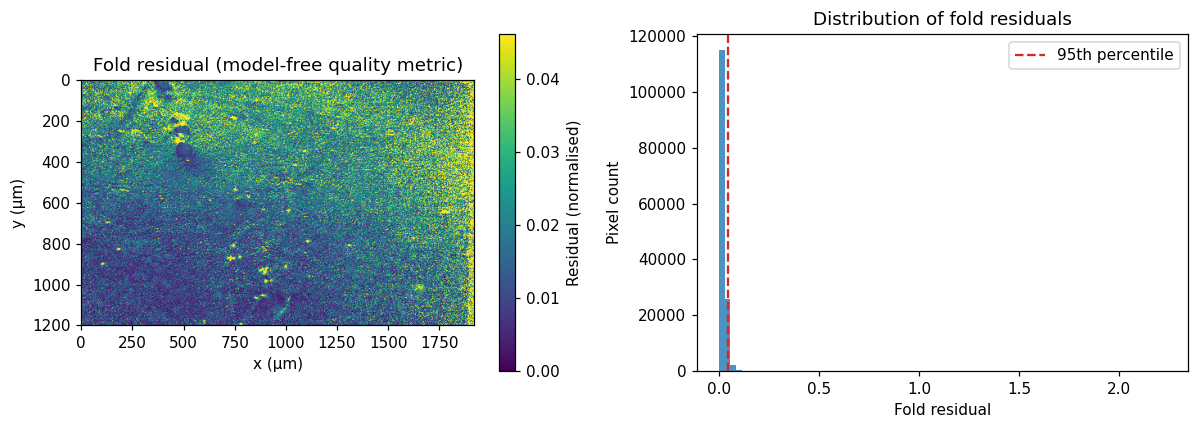

Fraction of pixels with residual > 95th percentile: 5.0%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im0 = axes[0].imshow(fold_res, extent=ext, cmap='viridis',
                     vmin=0, vmax=np.percentile(fold_res, 95))
axes[0].set_title('Fold residual (model-free quality metric)')
axes[0].set_xlabel('x (µm)')
axes[0].set_ylabel('y (µm)')
fig.colorbar(im0, ax=axes[0], label='Residual (normalised)')

axes[1].hist(fold_res.ravel(), bins=80, color='tab:blue', alpha=0.8)
axes[1].set_xlabel('Fold residual')
axes[1].set_ylabel('Pixel count')
axes[1].set_title('Distribution of fold residuals')
# Mark the 95th percentile as a suggested quality threshold
axes[1].axvline(np.percentile(fold_res, 95), color='tab:red', ls='--',
                label='95th percentile')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Fraction of pixels with residual > 95th percentile: '
      f'{(fold_res > np.percentile(fold_res, 95)).mean():.1%}')

## 6. Summary

In this tutorial we covered:

| Step | What we computed | Physical meaning |
|------|-----------------|------------------|
| Mean-spectrum fold | Global D_ZFS (sub-MHz precision) | Average temperature/strain calibration |
| Two-scale D_ZFS map | D(y,x) at coarse resolution + interpolated | Spatial temperature/strain map |
| Per-pixel fold | S_folded(δf) = S_low(D−δf) + S_high(D+δf) | √2 SNR, single Zeeman dip per pixel |
| Fold residual | R(y,x) normalised [0,1] | Data quality without any model fitting |

### Next steps

**Phase 2 (coming in QEP-011):** the `FoldedODMR` object produced here will
be passed directly to `FitManager` to get full per-pixel B111 maps with √2
better SNR than the current independent-range fitting.

The D_ZFS map also corrects a systematic error in the current B111 pipeline:
any spatial variation in D (from temperature or strain) currently appears as a
spurious B111 offset of ΔB = ΔD / γ ≈ 13 µT per MHz of D variation.